# Visualizing Graph Interactions with Chord Diagrams

Chord diagrams are a visually pleasing way to display complex interactions ("chords," "links," or "edges") between entities ("arcs" or "nodes") of a dataset. They are particularly useful for analyzing data involving systems of interacting bodies such as in population dynamics, economic modeling, and molecular simulation. The width of each chord of a chord diagram is scaled by interaction magnitude and organized hierarchically to make it easier to identify key interactions and trends.

In [ ]:
# Install the pyCirclize package to your conda enviornment:

%pip install pycirclize

In [18]:
from pycirclize import Circos
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Patch

Protein-glycan interaction data approximated from [Li & Minkara, 2025](https://pmc.ncbi.nlm.nih.gov/articles/PMC12418041/)

In [19]:
# Approximate H-bond fraction (%) values visually estimated from
# Li & Minkara, Biophysical Journal (2025), DOI:10.1016/j.bpj.2025.04.007, Figure 4.
# NOT the authors' original data — coarse color-matched estimates for teaching only.

residues = [
    "GLU_321", "ASN_323", "ASP_325", "GLU_329", "GLU_333",
    "THR_336", "ASN_341", "ARG_343", "GLU_347", "ARG_349",
]

glycans = [
    "MANa16MAN", "MANa13MAN", "MANa12MAN", "GLCa12GLC", "GLCa13GLC",
    "NAGb12MAN", "NAGb14MAN", "NAGb16MAN", "SIAa26GAL", "SIAa23GAL",
    "GALb14NAG", "FUCa16NAG", "MANa12MANa16MAN", "MANa12MANa12MAN",
    "MANa12MANa13MAN", "GLCa12GLCa13GLC", "GLCa13GLCa12GLC",
    "NAGb14NAG", "SIAa26GALb14NAG", "SIAa23GALb14NAG",
    "GALb14NAGb16MAN", "GALb14NAGb12MAN", "NAGb12MANa13MAN",
    "NAGb12MANa16MAN", "NAGb14MANa13MAN", "NAGb16MANa13MAN",
    "NAGb16MANb16MAN",
]

# rows = residues (order above), cols = glycans (order above)
data = np.array([
    # GLU_321
    [ 80, 75, 75, 70, 100, 70,  70, 150, 70, 100, 100, 70, 140, 70, 70, 60, 70,  20,  10,  70,  60, 150, 70, 150, 165, 70, 190],
    # ASN_323
    [  5,  5, 10,  5,   5,  5,   5,   5,  5,   5,   5,  5,   5,  5,  5,  5,  5,   5,   5,   5,   5,   5,  5,   5,   5,  5,   5],
    # ASP_325
    [ 40, 15, 90, 15,  50, 15,  90,  15, 50,  15,  15, 15, 100, 15, 15, 15, 70, 140,  15,  15,  40,  15, 15,  90, 90, 90,  15],
    # GLU_329
    [100,100,150, 30,  90, 90,  90, 100, 90, 100,  90, 90, 100, 30, 90, 30, 90,  30,  30,  70,  40,  30, 30, 100,100,100,  30],
    # GLU_333
    [ 10, 10, 10, 10,  55, 10,  50,  10, 10,  10,  10, 10,  10, 10,100, 10, 10,  10,  40,  10,  40,  10, 10,  15, 15, 15,  10],
    # THR_336
    [  3,  3,  3,  3,   3,  3,   3,   3,  3,   3,   3,  3,   3,  3,  3,  3,  3,   3,   3,   3,   3,   3,  3,   3,  3,  3,   3],
    # ASN_341
    [110,110,110, 30, 130,130, 110,  30,110, 110,  30,110,  30,110, 70, 30, 90,  30,  70,  30,  60, 150, 60, 100,100,100, 100],
    # ARG_343
    [ 15, 15, 15, 15,  95, 15,  90,  15, 85,  15,  90, 15,  15, 15,135, 15, 15,  15,  90,  90, 140, 150, 15,  90,140, 70,  90],
    # GLU_347
    [  5,  5,  5,  5,   5,  5,   5,   5,  5,   5,   5,  5,   5,  5,  5,  5,  5,   5,  50,   5,   5, 190,  5,   5,  5,  5,   5],
    # ARG_349
    [  5,  5,  5,  5,   5,  5,   5,   5,  5,   5,   5,  5,   5,  5,  5,  5,  5,   5,  55,   5,   5, 155,  5,  40,  5,  5,   5],
])

df = pd.DataFrame(data, index=residues, columns=glycans)
df.head()

,MANa16MAN,MANa13MAN,MANa12MAN,GLCa12GLC,GLCa13GLC,NAGb12MAN,NAGb14MAN,NAGb16MAN,SIAa26GAL,SIAa23GAL,GALb14NAG,FUCa16NAG,MANa12MANa16MAN,MANa12MANa12MAN,MANa12MANa13MAN,GLCa12GLCa13GLC,GLCa13GLCa12GLC,NAGb14NAG,SIAa26GALb14NAG,SIAa23GALb14NAG,GALb14NAGb16MAN,GALb14NAGb12MAN,NAGb12MANa13MAN,NAGb12MANa16MAN,NAGb14MANa13MAN,NAGb16MANa13MAN,NAGb16MANb16MAN
GLU_321,80,75,75,70,100,70,70,150,70,100,100,70,140,70,70,60,70,20,10,70,60,150,70,150,165,70,190
ASN_323,5,5,10,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
ASP_325,40,15,90,15,50,15,90,15,50,15,15,15,100,15,15,15,70,140,15,15,40,15,15,90,90,90,15
GLU_329,100,100,150,30,90,90,90,100,90,100,90,90,100,30,90,30,90,30,30,70,40,30,30,100,100,100,30
GLU_333,10,10,10,10,55,10,50,10,10,10,10,10,10,10,100,10,10,10,40,10,40,10,10,15,15,15,10


Text(0.5, 1.0, 'H-bonding between an SP-D lectin binding site and several glycan fragments')

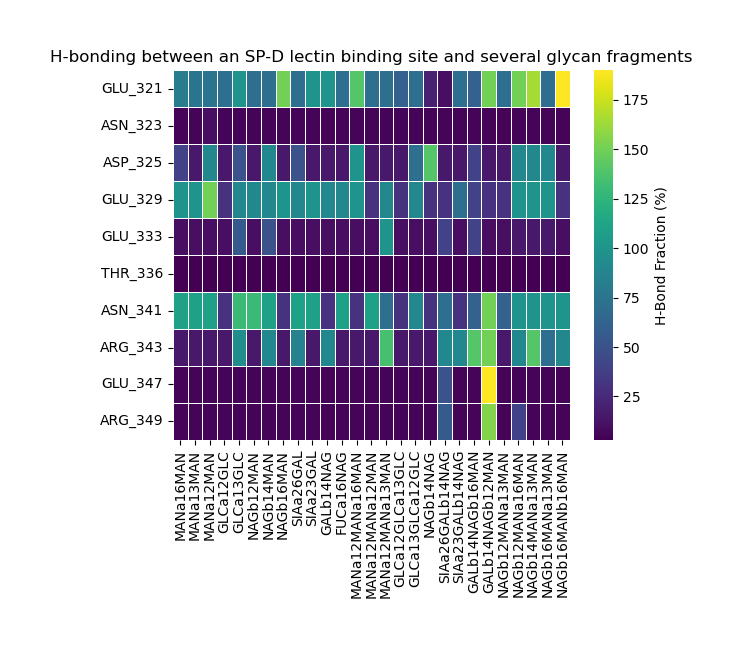

In [20]:
ax = sns.heatmap(
    data=df,
    cmap='viridis',
    cbar_kws={'label': 'H-Bond Fraction (%)'},
    linecolor='white',
    linewidth=.5,
)

ax.set_title('H-bonding between an SP-D lectin binding site and several glycan fragments')

## From heatmap to chord diagram

Handing this matrix straight to `Circos.chord_diagram()` with the defaults from the pyCirclize gallery produces a hairball. That is not a flaw in the library — it is the honest result of asking a chord diagram to do a heatmap's job without adapting it first.

The two plots fail differently. A heatmap gives every cell the same amount of space, so a weak interaction quietly occupies one dark square and costs the reader nothing. A chord diagram gives every link a *ribbon that sweeps across the whole circle*, so a 5% contact and a 190% contact demand equal attention. With 10 residues × 27 glycans, the defaults draw 270 ribbons, and the handful of interactions that matter are buried under the noise floor.

Four changes fix this, and they generalize to almost any dense chord diagram:

| Change | Why |
| --- | --- |
| **Threshold weak links away** | Removes ~155 noise-floor ribbons. Arcs left with no links (`ASN_323`, `THR_336`) are dropped too, so the ring has no empty stubs. |
| **Group and order the arcs** | Protein residues occupy one side of the ring, glycans the other, each sorted by total H-bonding. Every chord now crosses the middle, which makes the bipartite structure of the data visible in the layout itself. |
| **One colour family per node type** | `cmap` accepts a `{node: colour}` dict. Warm ramp for residues, cool ramp for glycans — you can tell what kind of node you are looking at without reading a label. |
| **Encode strength on the links** | Colour (`viridis`, the same scale as the heatmap above), opacity, and draw order all key off the H-bond fraction. This is what makes a strong chord pop the way a bright heatmap cell does. |

Everything below the first heading is a tunable parameter. Try raising `MIN_HBOND_FRACTION` to `45` or `85` and re-running the cell to see how much structure a stricter cutoff reveals — and think about how much real signal it throws away in exchange.


Text(0.5, 0.94, 'H-bonding between an SP-D lectin binding site and several glycan fragments')

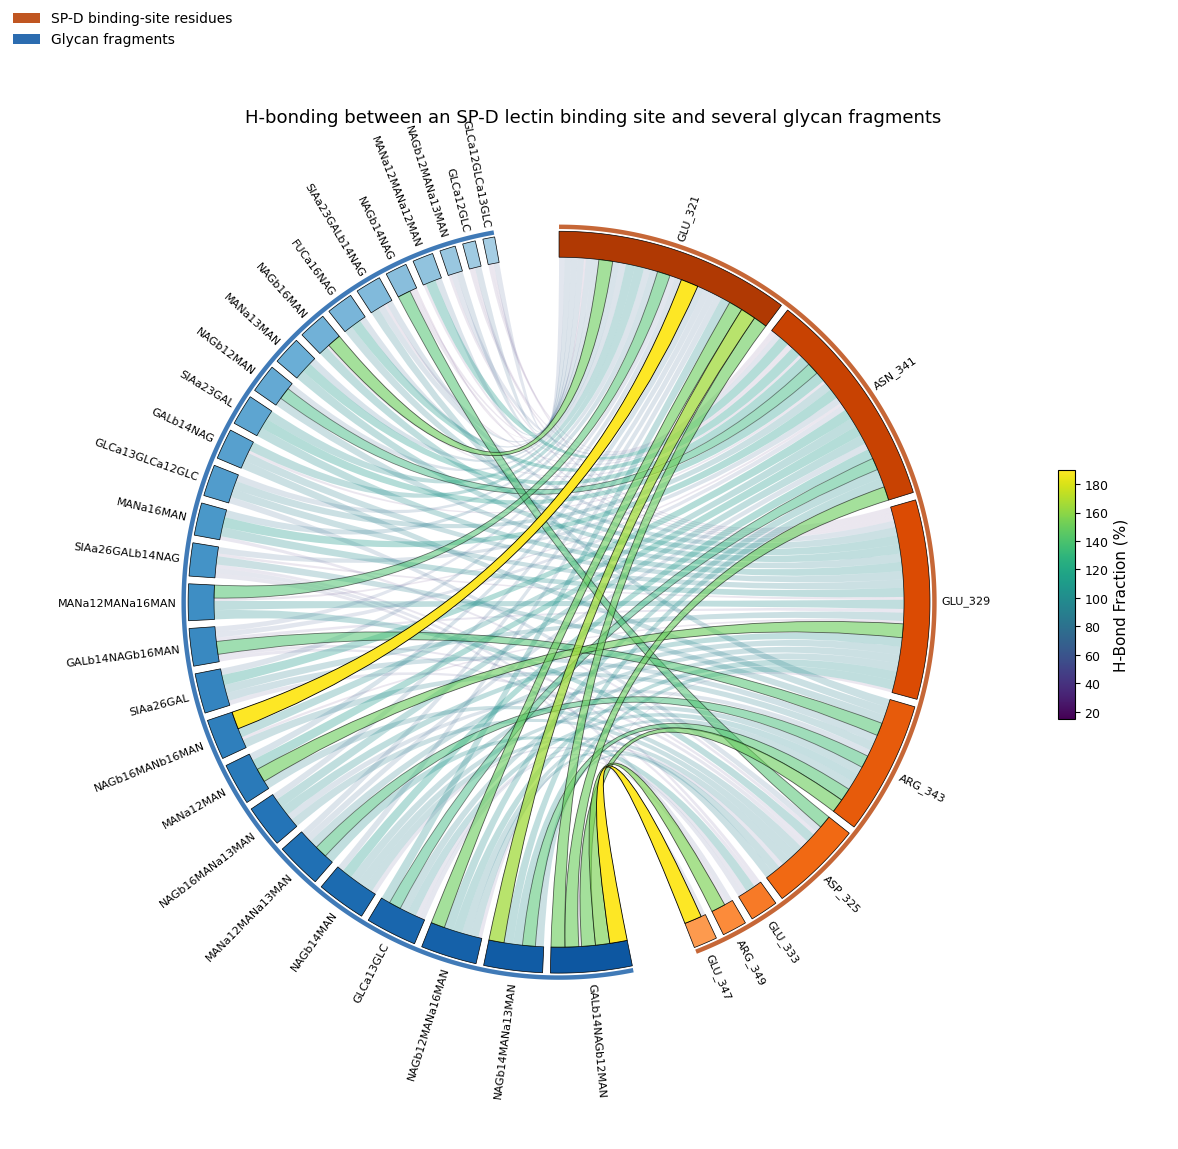

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Tunable parameters — edit these and re-run the cell to reshape the figure
# ─────────────────────────────────────────────────────────────────────────────
MIN_HBOND_FRACTION = 15         # links AT OR BELOW this % are dropped entirely
                                # (try 45 or 85 to keep only the strongest contacts)

LINK_CMAP        = 'viridis'    # same colormap as the heatmap above
RESIDUE_ARC_CMAP = 'Oranges'    # warm family  -> protein side of the ring
GLYCAN_ARC_CMAP  = 'Blues'      # cool family  -> glycan side of the ring

ALPHA_FLOOR   = 0.10            # opacity of the weakest link that survives
ALPHA_GAMMA   = 2.2             # >1 fades mid-strength links harder
OUTLINE_ABOVE = 0.60            # links in the top 40% of the scale get a dark edge

BASE_SPACE, GROUP_SPACE = 1.2, 10.0   # degrees between arcs / between the two groups
LABEL_SIZE = 8
FIGSIZE    = (11, 11)

TITLE = 'H-bonding between an SP-D lectin binding site and several glycan fragments'

# ─────────────────────────────────────────────────────────────────────────────
# 1. Threshold out the noise
# ─────────────────────────────────────────────────────────────────────────────
# A heatmap can afford to show every cell, because a weak cell is simply a dark
# square that costs no attention. A chord diagram cannot: every link is drawn as
# a full ribbon sweeping across the circle, so a 5% contact costs just as much
# ink as a 190% one. Dropping the noise floor is the single biggest readability
# win available here.
mat = df.where(df > MIN_HBOND_FRACTION, 0)

# Arcs that lost all of their links would otherwise sit on the ring as empty
# stubs, so drop those rows/columns too (at 15% this removes ASN_323 and THR_336).
mat = mat.loc[mat.sum(axis=1) > 0, mat.sum(axis=0) > 0]

# ─────────────────────────────────────────────────────────────────────────────
# 2. Order the ring so the two node types are contiguous
# ─────────────────────────────────────────────────────────────────────────────
# Within each group, sort from strongest total H-bonding to weakest so the busiest
# arcs sit next to each other instead of being scattered around the circle.
residue_order = mat.sum(axis=1).sort_values(ascending=False).index.tolist()
glycan_order  = mat.sum(axis=0).sort_values(ascending=False).index.tolist()
node_order    = residue_order + glycan_order

# `space` accepts one gap per sector, so we can widen just the two gaps that fall
# at the group boundaries. This opens a visible channel between protein and glycan.
space = [BASE_SPACE] * len(node_order)
space[len(residue_order) - 1] = GROUP_SPACE   # gap after the last residue
space[-1] = GROUP_SPACE                       # gap after the last glycan

# ─────────────────────────────────────────────────────────────────────────────
# 3. Two colour families for the arcs, one per node type
# ─────────────────────────────────────────────────────────────────────────────
# `cmap` also accepts a {node_name: colour} dict, which lets us hand the protein
# residues a warm ramp and the glycans a cool one. Shading each ramp from dark to
# light in sort order keeps neighbouring arcs distinguishable within a group,
# while the hue still reads as "one group" at a glance.
arc_colors = {}
for name, i in zip(residue_order, np.linspace(0.85, 0.45, len(residue_order))):
    arc_colors[name] = plt.get_cmap(RESIDUE_ARC_CMAP)(i)
for name, i in zip(glycan_order, np.linspace(0.85, 0.35, len(glycan_order))):
    arc_colors[name] = plt.get_cmap(GLYCAN_ARC_CMAP)(i)

# ─────────────────────────────────────────────────────────────────────────────
# 4. Colour and fade each link by its H-bond fraction
# ─────────────────────────────────────────────────────────────────────────────
# This is what makes a strong chord behave like a bright heatmap cell. Three cues
# stack on the same number:
#   colour  -> viridis, the same scale as the heatmap above
#   opacity -> a gamma ramp, so weak links recede into faint background context
#   z-order -> strong links are drawn last, on top of everything else
# The scale starts at the threshold rather than at 0, so the surviving links use
# the full range of the colormap instead of being crammed into its dark end.
cmap = plt.get_cmap(LINK_CMAP)
vmin, vmax = MIN_HBOND_FRACTION, float(mat.values.max())
norm = Normalize(vmin=vmin, vmax=vmax)

link_colors, link_styles = [], {}
for residue in mat.index:
    for glycan in mat.columns:
        value = mat.loc[residue, glycan]
        if value <= 0:
            continue
        f = float(norm(value))                       # 0 = threshold, 1 = strongest
        link_colors.append((residue, glycan, cmap(f)))
        link_styles[(residue, glycan)] = dict(
            alpha=ALPHA_FLOOR + (1 - ALPHA_FLOOR) * f ** ALPHA_GAMMA,
            zorder=1 + 10 * f,
            lw=0.6 if f > OUTLINE_ABOVE else 0.0,
            ec='black' if f > OUTLINE_ABOVE else 'none',
        )

# pyCirclize hands this function the two endpoint names of a link and applies
# whatever keyword arguments we return to that one link.
def style_link(from_label, to_label):
    return link_styles.get((from_label, to_label)) or link_styles.get((to_label, from_label))

# ─────────────────────────────────────────────────────────────────────────────
# 5. Draw
# ─────────────────────────────────────────────────────────────────────────────
circos = Circos.chord_diagram(
    mat,
    space=space,
    r_lim=(93, 100),
    cmap=arc_colors,
    link_cmap=link_colors,
    order=node_order,
    label_kws=dict(r=103, size=LABEL_SIZE, orientation='vertical', color='black'),
    link_kws=dict(direction=0),
    link_kws_handler=style_link,
)

# A solid band outside each group restates the protein/glycan split, so the split
# survives being printed in greyscale or read by a colour-blind viewer.
group_colors = {'SP-D binding-site residues': ('#c05621', residue_order),
                'Glycan fragments':           ('#2b6cb0', glycan_order)}
for label, (color, names) in group_colors.items():
    circos.rect(r_lim=(100.6, 101.8), deg_lim=circos.get_group_sectors_deg_lim(names),
                fc=color, ec='none', alpha=0.9)

circos.colorbar(
    bounds=(1.14, 0.35, 0.022, 0.32),
    vmin=vmin, vmax=vmax, cmap=LINK_CMAP,
    label='H-Bond Fraction (%)',
    label_kws=dict(size=11), tick_kws=dict(labelsize=9),
)

fig = circos.plotfig(figsize=FIGSIZE)
fig.legend(handles=[Patch(fc=c, label=l) for l, (c, _) in group_colors.items()],
           loc='upper left', frameon=False, fontsize=10)
fig.suptitle(TITLE, size=13, y=0.94)

Resources:

- [Chord diagram plotting code from pyCirclize](https://moshi4.github.io/pyCirclize/chord_diagram/)
- [Frequency Chord diagram and Heatmap in Python](https://github.com/scverse/liana-py/issues/85)
- [Chord diagram example from Python Graph Gallery](https://python-graph-gallery.com/chord-diagram-python-chord/)
- [Chord diagrams of protein interaction networks in Python](https://medium.com/data-science/chord-diagrams-of-protein-interaction-networks-in-python-9589affc8b91)
- [Decoding SP-D and glycan binding mechanisms using a novel computational workflow](https://pmc.ncbi.nlm.nih.gov/articles/PMC12418041/)